<a href="https://colab.research.google.com/github/Chase-Troy/Course-Assignments/blob/main/Diabetes_Patients.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Loading Dataset


In [1]:
from sklearn.datasets import load_diabetes

In [2]:
diabetes = load_diabetes()

Displaying the Dataset’s Description

In [3]:
print(diabetes.DESCR)

.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

:Number of Instances: 442

:Number of Attributes: First 10 columns are numeric predictive values

:Target: Column 11 is a quantitative measure of disease progression one year after baseline

:Attribute Information:
    - age     age in years
    - sex
    - bmi     body mass index
    - bp      average blood pressure
    - s1      tc, total serum cholesterol
    - s2      ldl, low-density lipoproteins
    - s3      hdl, high-density lipoproteins
    - s4      tch, total cholesterol / HDL
    - s5      ltg, possibly log of serum triglycerides level
    - s6      glu, blood sugar level

Note: Each of these 10 feature variables have bee

In [4]:
diabetes.data.shape

(442, 10)

In [5]:
diabetes.target.shape

(442,)

In [6]:
diabetes.feature_names

['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']

Exploring the Data with a Pandas

In [7]:
import pandas as pd

In [8]:
pd.set_option('display.precision',4)

In [9]:
diabetes_df = pd.DataFrame(diabetes.data,
                             columns=diabetes.feature_names)

In [10]:
diabetes_df['bmi'] = pd.Series(diabetes.target)

In [11]:
diabetes_df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.0381,0.0507,151.0,0.0219,-0.0442,-0.0348,-0.0434,-0.0026,0.0199,-0.0176
1,-0.0019,-0.0446,75.0,-0.0263,-0.0084,-0.0192,0.0744,-0.0395,-0.0683,-0.0922
2,0.0853,0.0507,141.0,-0.0057,-0.0456,-0.0342,-0.0324,-0.0026,0.0029,-0.0259
3,-0.0891,-0.0446,206.0,-0.0367,0.0122,0.0250,-0.0360,0.0343,0.0227,-0.0094
4,0.0054,-0.0446,135.0,0.0219,0.0039,0.0156,0.0081,-0.0026,-0.0320,-0.0466


In [12]:
diabetes_df.describe()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
count,4.4200e+02,4.4200e+02,442.0000,4.4200e+02,4.4200e+02,4.4200e+02,4.4200e+02,4.4200e+02,4.4200e+02,4.4200e+02
mean,-2.5118e-19,1.2308e-17,152.1335,-4.7976e-17,-1.3815e-17,3.9184e-17,-5.7772e-18,-9.0425e-18,9.2937e-17,1.1303e-17
std,4.7619e-02,4.7619e-02,77.0930,4.7619e-02,4.7619e-02,4.7619e-02,4.7619e-02,4.7619e-02,4.7619e-02,4.7619e-02
min,-1.0723e-01,-4.4642e-02,25.0000,-1.1240e-01,-1.2678e-01,-1.1561e-01,-1.0231e-01,-7.6395e-02,-1.2610e-01,-1.3777e-01
25%,-3.7299e-02,-4.4642e-02,87.0000,-3.6656e-02,-3.4248e-02,-3.0358e-02,-3.5117e-02,-3.9493e-02,-3.3246e-02,-3.3179e-02
50%,5.3831e-03,-4.4642e-02,140.5000,-5.6704e-03,-4.3209e-03,-3.8191e-03,-6.5845e-03,-2.5923e-03,-1.9472e-03,-1.0777e-03
75%,3.8076e-02,5.0680e-02,211.5000,3.5644e-02,2.8358e-02,2.9844e-02,2.9312e-02,3.4309e-02,3.2432e-02,2.7917e-02
max,1.1073e-01,5.0680e-02,346.0000,1.3204e-01,1.5391e-01,1.9879e-01,1.8118e-01,1.8523e-01,1.3360e-01,1.3561e-01


Visualizing the Features

In [13]:
sample_df = diabetes_df.sample(frac=0.1, random_state=17)

In [14]:
import matplotlib.pyplot as plt


In [15]:
import seaborn as sns

In [16]:
sns.set_style('whitegrid')

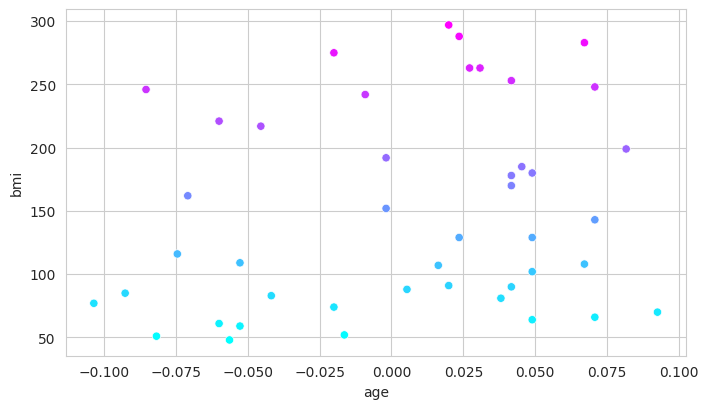

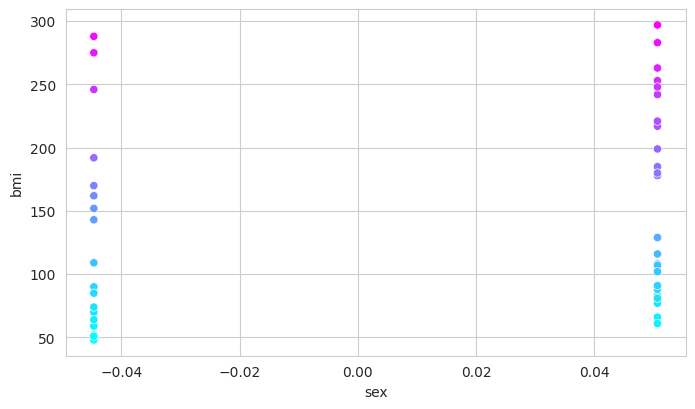

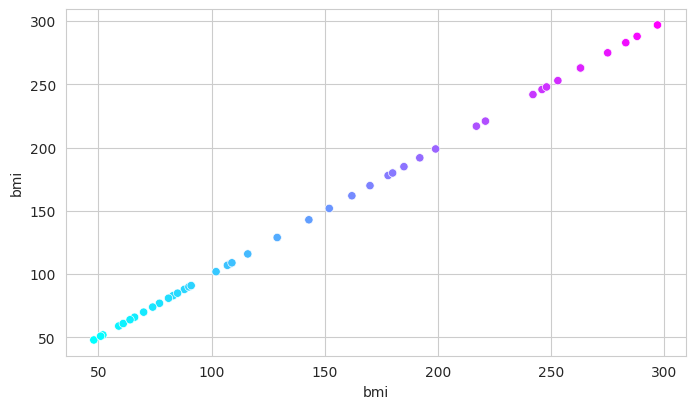

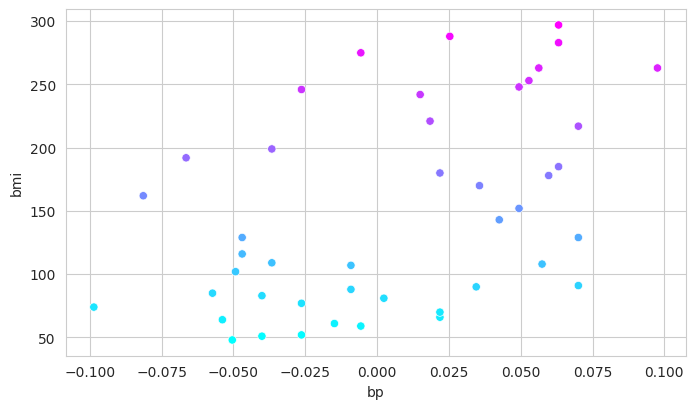

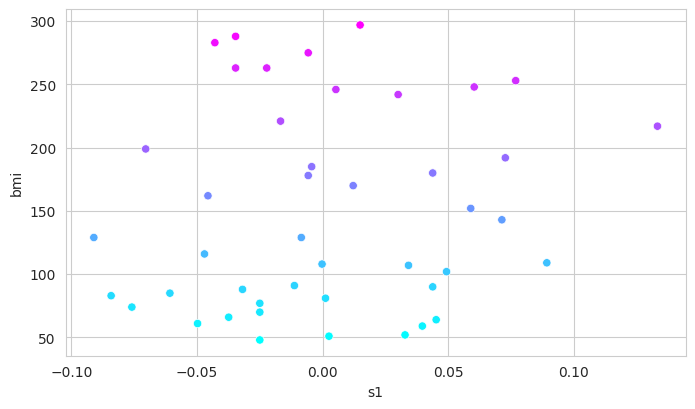

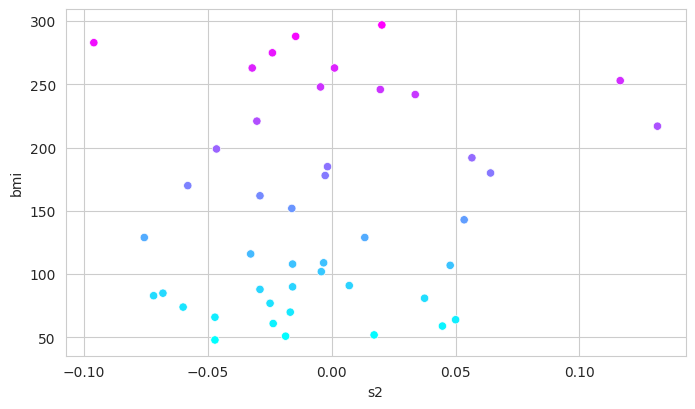

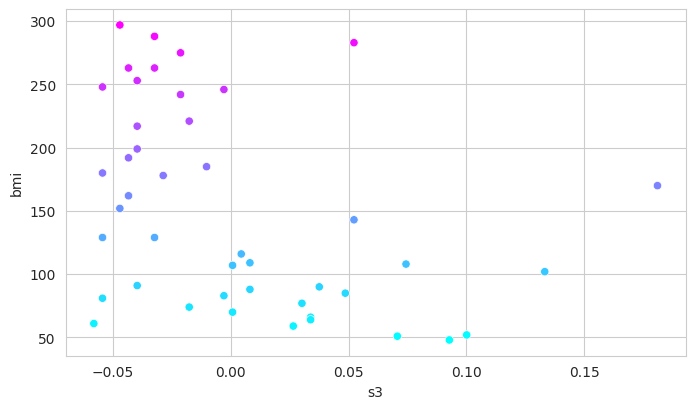

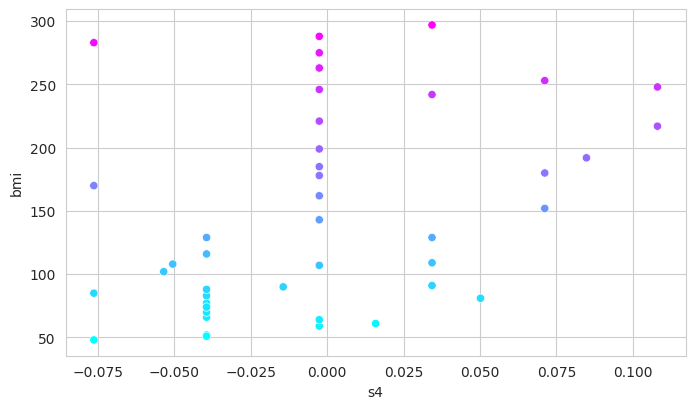

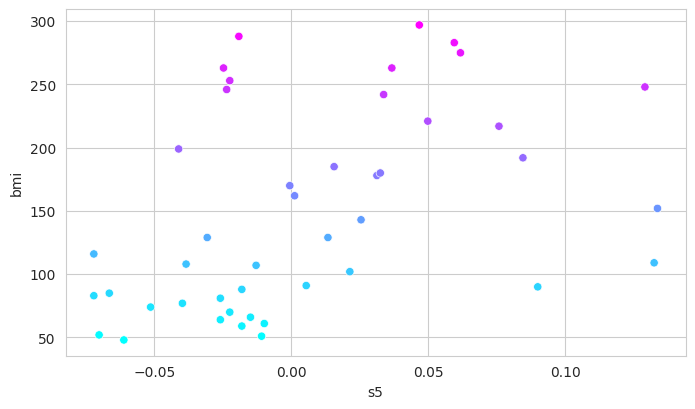

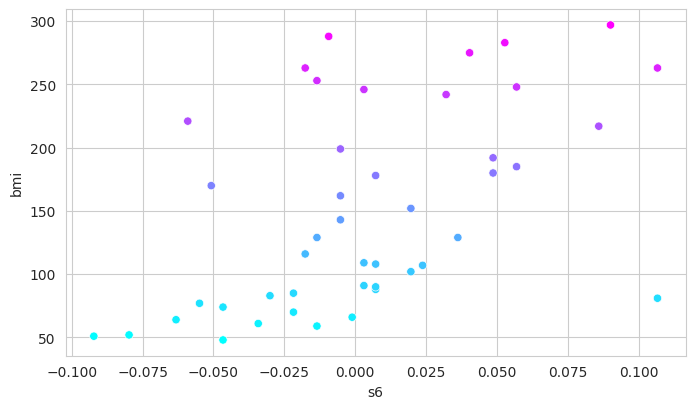

In [17]:
for feature in diabetes.feature_names:
    plt.figure(figsize=(8, 4.5))  # 8"-by-4.5" Figure
    sns.scatterplot(data=sample_df, x=feature,
                    y='bmi', hue='bmi',
                    palette='cool', legend=False)

Splitting the Data for Training and Testing Using `train_test_split`  

In [18]:
from sklearn.model_selection import train_test_split

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    diabetes.data, diabetes.target, random_state=11)

In [20]:
X_train.shape

(331, 10)

In [21]:
X_test.shape

(111, 10)

Training the Model

In [22]:
from sklearn.linear_model import LinearRegression

In [23]:
linear_regression = LinearRegression()

In [24]:
linear_regression.fit(X=X_train, y=y_train)

LinearRegression()

In [25]:
for i, name in enumerate(diabetes.feature_names):
    print(f'{name:>10}: {linear_regression.coef_[i]}')

       age: -60.21981405677291
       sex: -266.45705232203574
       bmi: 523.0634112596993
        bp: 310.5134699670048
        s1: -336.1614738106944
        s2: 137.3392923842451
        s3: -131.13923283453653
        s4: -1.1492348017315557
        s5: 622.3286855688128
        s6: 60.466457691682535


In [26]:
linear_regression.intercept_

np.float64(152.22822762230342)

Testing the Model

In [27]:
predicted = linear_regression.predict(X_test)

In [28]:
expected = y_test

In [29]:
predicted[:5]

array([115.46474836,  83.4585369 , 160.77727376, 187.65710274,
        72.72122197])

In [30]:
expected[:5]

array([ 79.,  55., 109., 178.,  39.])

Visualizing the Expected vs. Predicted bmi
Create a `DataFrame` containing columns for the expected and predicted values:

In [31]:
df=pd.DataFrame({'Expected': expected, 'Predicted': predicted})

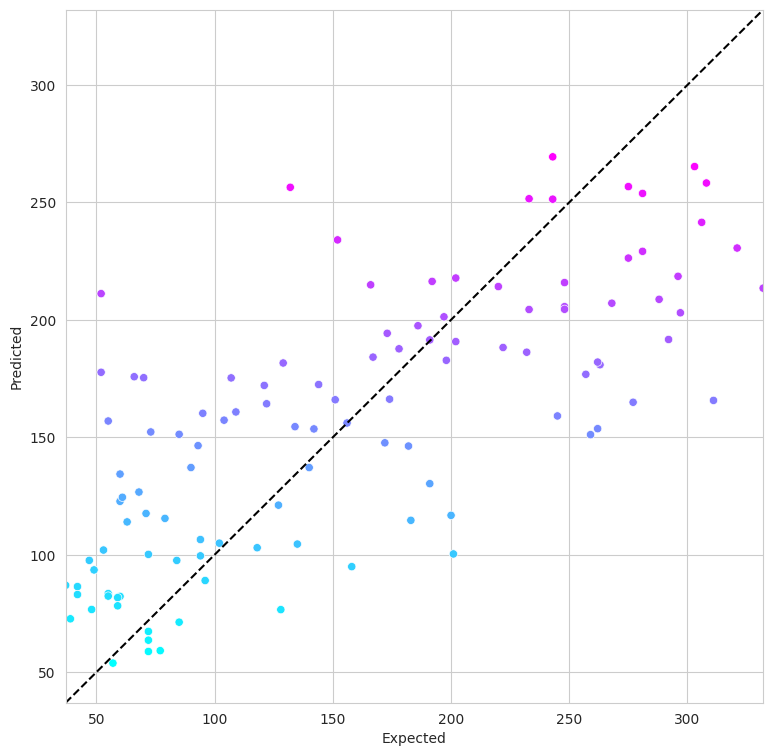

In [32]:
figure = plt.figure(figsize=(9, 9))

axes = sns.scatterplot(data=df, x='Expected', y='Predicted',
    hue='Predicted', palette='cool', legend=False)

start = min(expected.min(), predicted.min())

end = max(expected.max(), predicted.max())

axes.set_xlim(start, end)

axes.set_ylim(start, end)

line = plt.plot([start, end], [start, end], 'k--')

Regression Model Metrics

In [33]:
from sklearn import metrics

In [34]:
metrics.r2_score(expected, predicted)

0.5322429620529407

In [35]:
from sklearn.linear_model import ElasticNet, Lasso, Ridge

In [36]:
estimators = {
    'LinearRegression': linear_regression,
    'ElasticNet': ElasticNet(),
    'Lasso': Lasso(),
    'Ridge': Ridge()
}

Choosing the Best Model

In [37]:
from sklearn.model_selection import KFold, cross_val_score

In [38]:
for estimator_name, estimator_object in estimators.items():
    kfold = KFold(n_splits=10, random_state=11, shuffle=True)
    scores = cross_val_score(estimator=estimator_object,
        X=diabetes.data, y=diabetes.target, cv=kfold,
        scoring='r2')
    print(f'{estimator_name:>16}: ' +
          f'mean of r2 scores={scores.mean():.3f}')

LinearRegression: mean of r2 scores=0.475
      ElasticNet: mean of r2 scores=-0.002
           Lasso: mean of r2 scores=0.339
           Ridge: mean of r2 scores=0.421
